<a href="https://colab.research.google.com/github/dglloyde/uk-air-quality-analysis/blob/main/notebooks/P1_air_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Loading the Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving PiccadillyAirQualityDataHourly.csv to PiccadillyAirQualityDataHourly.csv


In [1]:
import pandas as pd

rawAQD = pd.read_csv('PiccadillyAirQualityDataHourly.csv', skiprows=10)

## Overview of Raw Data

In [36]:
rawAQD.head(60)

,date,time,no2,status
0,2018-01-01,01:00:00,37.57883,V ugm-3
1,2018-01-01,02:00:00,25.35174,V ugm-3
2,2018-01-01,03:00:00,18.03759,V ugm-3
3,2018-01-01,04:00:00,23.24502,V ugm-3
4,2018-01-01,05:00:00,23.04107,V ugm-3
5,2018-01-01,06:00:00,19.01839,V ugm-3
6,2018-01-01,07:00:00,16.18447,V ugm-3
7,2018-01-01,08:00:00,19.02126,V ugm-3
8,2018-01-01,09:00:00,22.42177,V ugm-3
9,2018-01-01,10:00:00,17.21377,V ugm-3


In [30]:
rawAQD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43825 entries, 0 to 43824
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              43825 non-null  object
 1   Time              43824 non-null  object
 2   Nitrogen dioxide  43824 non-null  object
 3   Status            43824 non-null  object
dtypes: object(4)
memory usage: 1.3+ MB


In [31]:
rawAQD.describe()

,Date,Time,Nitrogen dioxide,Status
count,43825,43824,43824,43824
unique,1827,24,42985,1
top,2022-12-31,01:00:00,No data,V ugm-3
freq,24,1826,652,43824


## Cleaning Data

In [2]:
rawAQD.columns = ["date", "time", "no2", "status"]

In [3]:
rawAQD['no2'] = pd.to_numeric(rawAQD['no2'], errors='coerce')
rawAQD = rawAQD[rawAQD['status'].isin(["V ugm-3"])]

In [4]:
print(f"Total rows: {len(rawAQD)}")
print(f"Missing NO2 values: {rawAQD['no2'].isna().sum()}")
print(f"That is {rawAQD['no2'].isna().mean()*100:.1f}% of the data")

Total rows: 43824
Missing NO2 values: 652
That is 1.5% of the data


### Creating Proper Time Index

In [5]:
mask_24 = rawAQD['time'] == '24:00:00'
rawAQD.loc[mask_24, 'time'] = '00:00:00'
rawAQD.loc[mask_24, 'date'] = (
    pd.to_datetime(rawAQD.loc[mask_24, 'date']) + pd.Timedelta(days=1)
).dt.strftime('%Y-%m-%d')

rawAQD['datetime'] = pd.to_datetime(rawAQD['date'] + ' ' + rawAQD['time'])
rawAQD = rawAQD.set_index('datetime')
rawAQD = rawAQD.drop(columns = ['date', 'time', 'status'])
rawAQD = rawAQD.sort_index()

In [6]:
cleanAQD = rawAQD.copy()
cleanAQD.to_csv('cleanAQD.csv')

In [46]:
rawAQD.head(30)

,no2
datetime,
2018-01-01 01:00:00,37.57883
2018-01-01 02:00:00,25.35174
2018-01-01 03:00:00,18.03759
2018-01-01 04:00:00,23.24502
2018-01-01 05:00:00,23.04107
2018-01-01 06:00:00,19.01839
2018-01-01 07:00:00,16.18447
2018-01-01 08:00:00,19.02126
2018-01-01 09:00:00,22.42177


## EDA

In [7]:
print(cleanAQD["no2"].describe())

count    43172.000000
mean        31.324369
std         17.865794
min          2.007220
25%         17.333845
50%         27.740895
75%         42.112930
max        159.577850
Name: no2, dtype: float64


In [8]:
cleanAQD['year'] = cleanAQD.index.year
print(cleanAQD.groupby('year')['no2'].describe().round(1))

       count  mean   std   min   25%   50%   75%    max
year                                                   
2018  8681.0  34.6  16.5   5.2  21.9  32.2  45.1  159.6
2019  8659.0  36.3  18.4   3.9  21.7  33.8  47.6  118.5
2020  8713.0  27.1  17.1   2.0  13.6  22.9  36.8  103.7
2021  8437.0  29.5  17.1   2.9  16.2  25.5  39.7  112.9
2022  8681.0  29.0  18.3   3.1  15.6  24.2  37.7  144.4
2023     1.0  23.2   NaN  23.2  23.2  23.2  23.2   23.2


### Distributions and Seasonality

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

/tmp/ipykernel_27784/3347597703.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/3347597703.py:10: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_raw_timeseries.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


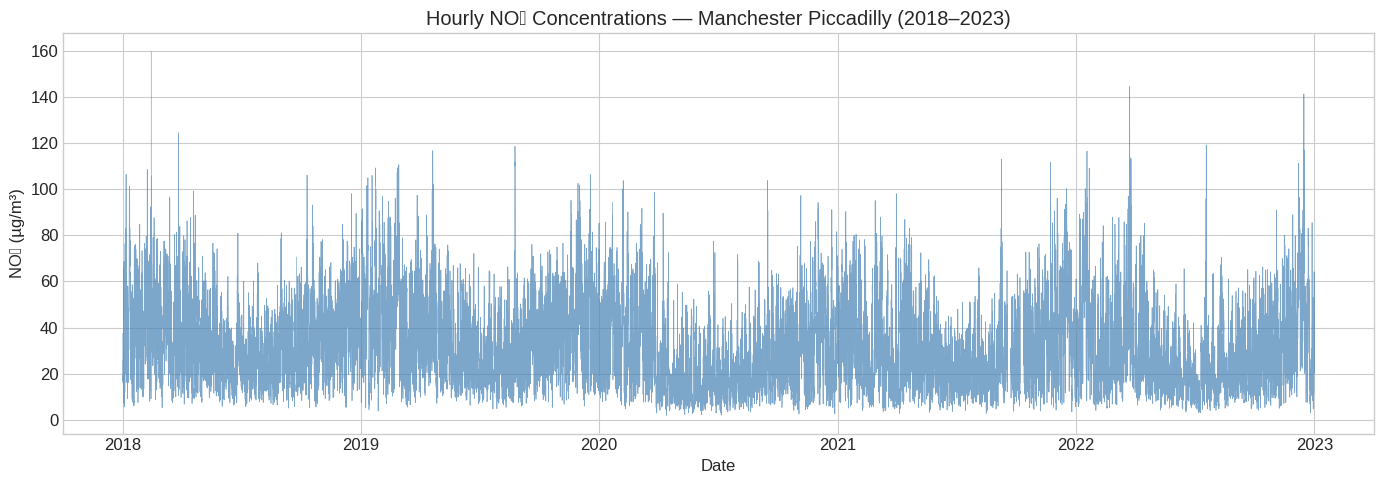

In [10]:
fig, ax = plt.subplots()

ax.plot(cleanAQD.index, cleanAQD['no2'], linewidth=0.5, color='steelblue', alpha=0.7)

ax.set_title('Hourly NO₂ Concentrations — Manchester Piccadilly (2018–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_raw_timeseries.png', dpi=150)
plt.show()

/tmp/ipykernel_27784/1609254731.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/1609254731.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_daily_mean.png', dpi=150)


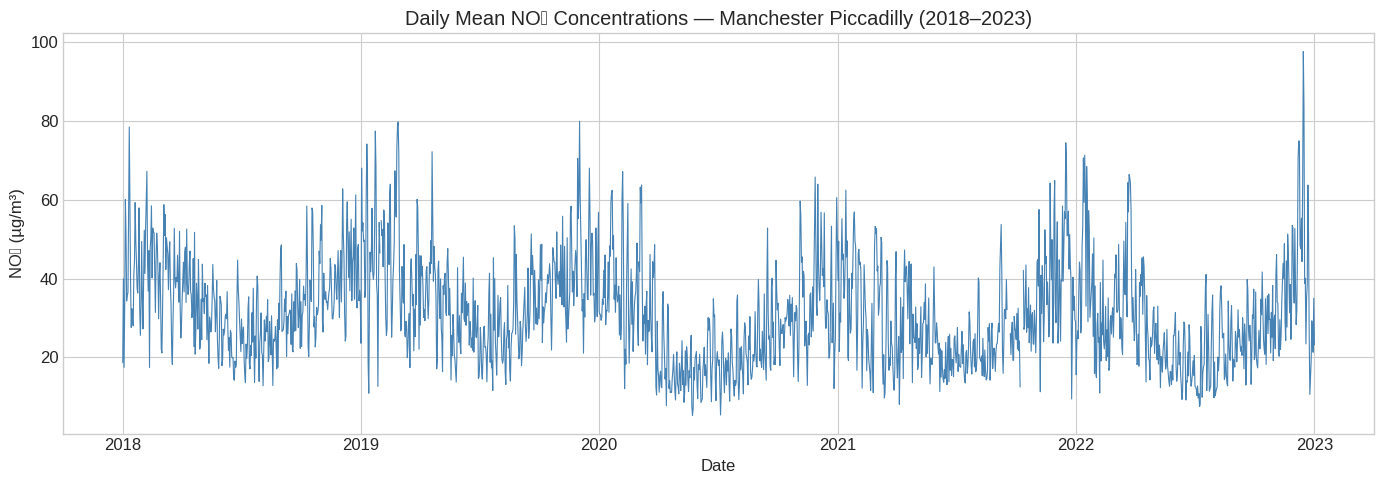

In [11]:
daily = cleanAQD['no2'].resample('D').mean()

fig, ax = plt.subplots()

ax.plot(daily.index, daily.values, linewidth=0.8, color='steelblue')

ax.set_title('Daily Mean NO₂ Concentrations — Manchester Piccadilly (2018–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_daily_mean.png', dpi=150)
plt.show()

/tmp/ipykernel_27784/2394836278.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/2394836278.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_distribution.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


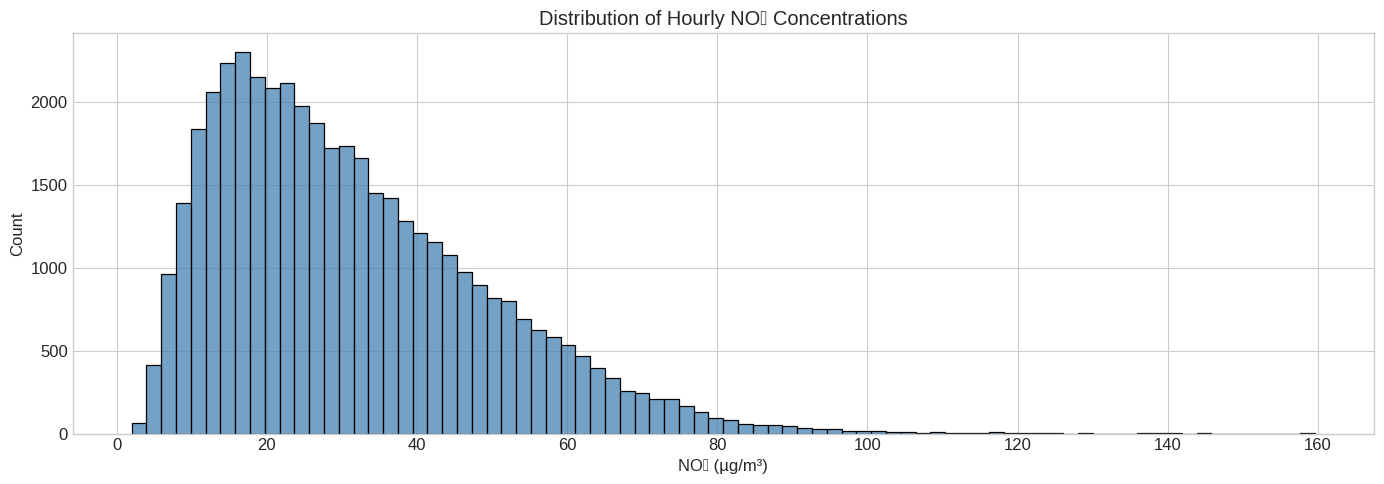

In [12]:
import seaborn as sns

fig, ax = plt.subplots()

sns.histplot(cleanAQD['no2'].dropna(), bins=80, color='steelblue', ax=ax)

ax.set_title('Distribution of Hourly NO₂ Concentrations')
ax.set_xlabel('NO₂ (µg/m³)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('no2_distribution.png', dpi=150)
plt.show()

/tmp/ipykernel_27784/554924950.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/554924950.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_monthly.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


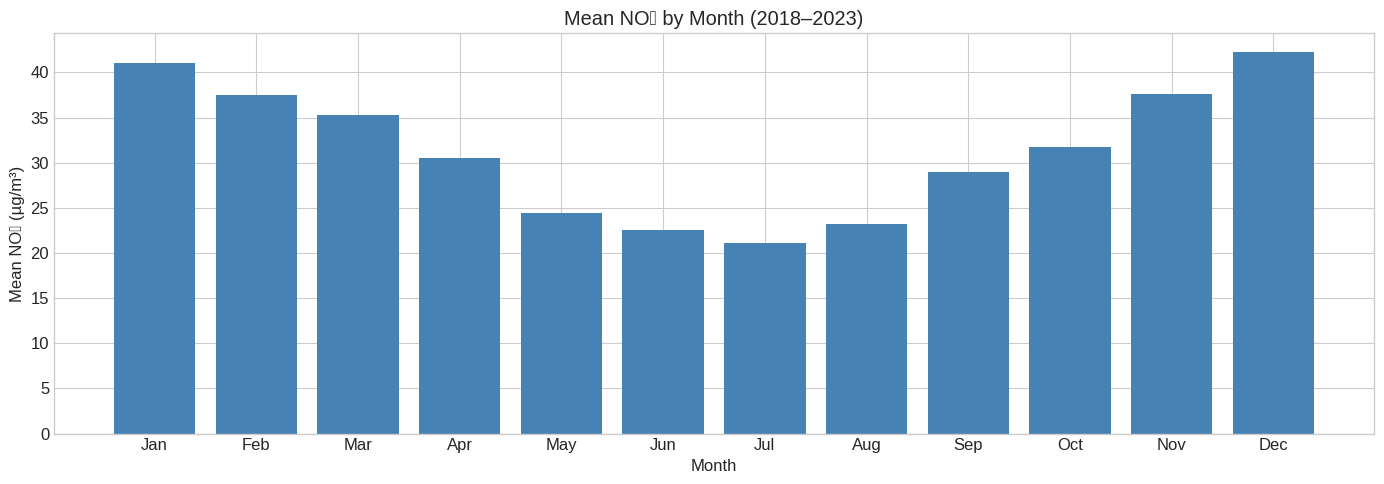

In [13]:
cleanAQD['month'] = cleanAQD.index.month

monthly_means = cleanAQD.groupby('month')['no2'].mean()

fig, ax = plt.subplots()

ax.bar(monthly_means.index, monthly_means.values, color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Mean NO₂ by Month (2018–2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Mean NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_monthly.png', dpi=150)

/tmp/ipykernel_27784/2864556408.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/2864556408.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_hourly.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


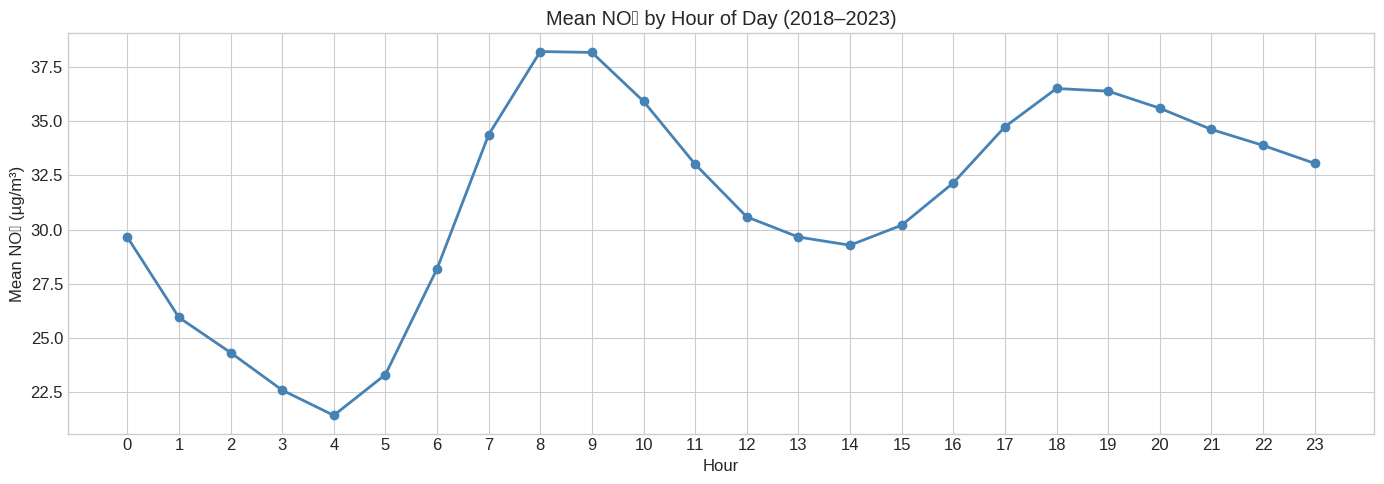

In [14]:
cleanAQD['hour'] = cleanAQD.index.hour

hourly_means = cleanAQD.groupby('hour')['no2'].mean()

fig, ax = plt.subplots()

ax.plot(hourly_means.index, hourly_means.values,
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Mean NO₂ by Hour of Day (2018–2023)')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean NO₂ (µg/m³)')
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('no2_hourly.png', dpi=150)
plt.show()

### Outliers and Anomalies

In [15]:
mean = cleanAQD['no2'].mean()
std = cleanAQD['no2'].std()
threshold = mean + 3 * std

outliers = cleanAQD[cleanAQD['no2'] > threshold]

print(f"Mean NO₂: {mean:.1f} µg/m³")
print(f"Standard deviation: {std:.1f} µg/m³")
print(f"Outlier threshold (mean + 3σ): {threshold:.1f} µg/m³")
print(f"Number of outliers flagged: {len(outliers)}")
print(f"\nTop 10 highest readings:")
print(cleanAQD['no2'].nlargest(10))

Mean NO₂: 31.3 µg/m³
Standard deviation: 17.9 µg/m³
Outlier threshold (mean + 3σ): 84.9 µg/m³
Number of outliers flagged: 352

Top 10 highest readings:
datetime
2018-02-13 13:00:00    159.57785
2022-03-23 21:00:00    144.43189
2022-12-15 20:00:00    141.23230
2022-12-15 21:00:00    140.50603
2022-12-15 19:00:00    139.38832
2022-12-15 22:00:00    137.05487
2022-12-15 18:00:00    128.15315
2018-03-27 08:00:00    124.36468
2022-12-15 17:00:00    123.72048
2022-12-15 23:00:00    122.34230
Name: no2, dtype: float64


/tmp/ipykernel_27784/1096461604.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/1096461604.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_outliers.png', dpi=150)


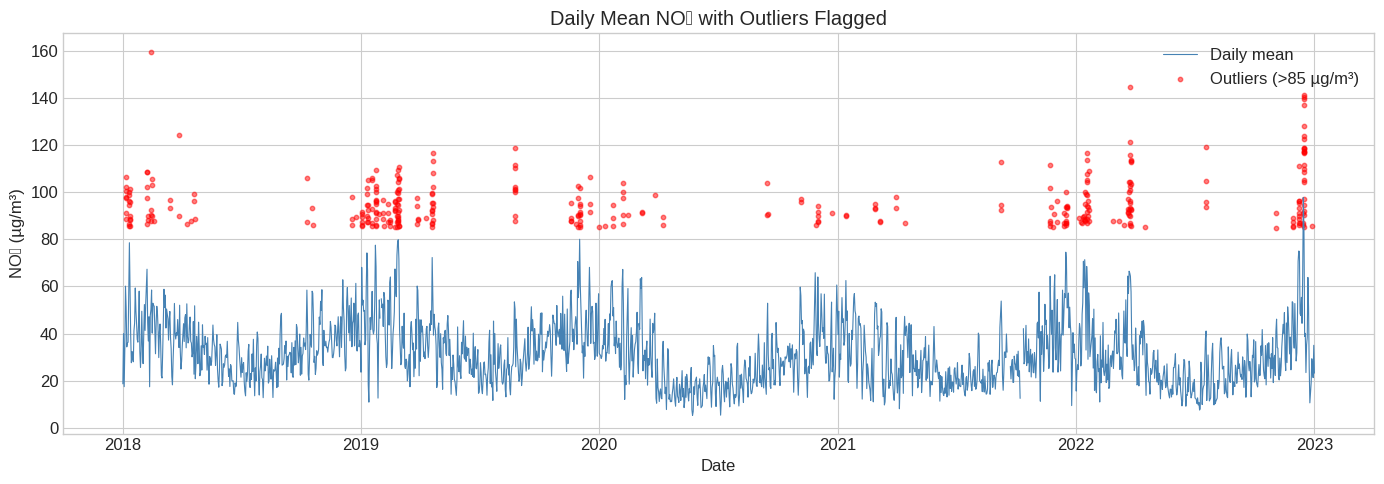

In [16]:
fig, ax = plt.subplots()

ax.plot(daily.index, daily.values, linewidth=0.8,
        color='steelblue', label='Daily mean')
ax.scatter(outliers.index, outliers['no2'],
           color='red', s=10, alpha=0.5, label=f'Outliers (>{threshold:.0f} µg/m³)')

ax.set_title('Daily Mean NO₂ with Outliers Flagged')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')
ax.legend()

plt.tight_layout()
plt.savefig('no2_outliers.png', dpi=150)
plt.show()

## Time Series Decomposition

/tmp/ipykernel_27784/1693200413.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/1693200413.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_classical_decomposition.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


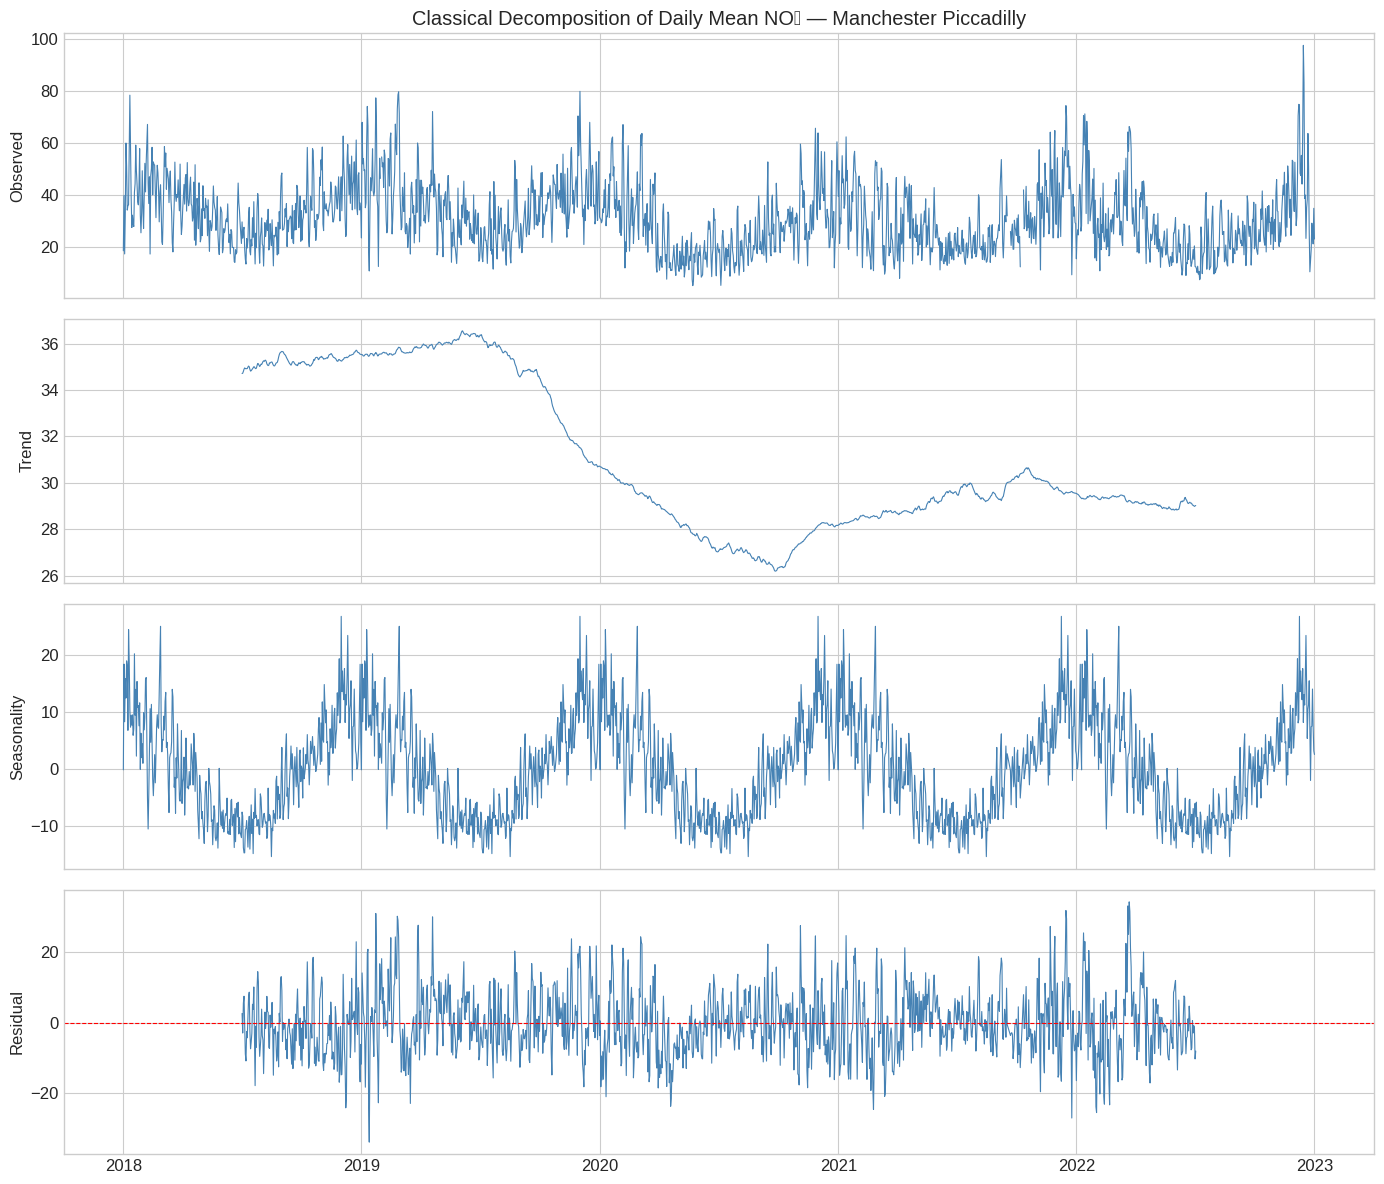

In [17]:
daily = cleanAQD['no2'].resample('D').mean()

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(daily.dropna(), model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Observed')
axes[0].set_title('Classical Decomposition of Daily Mean NO₂ — Manchester Piccadilly')

axes[1].plot(result.trend.index, result.trend.values, color='steelblue', linewidth=0.8)
axes[1].set_ylabel('Trend')

axes[2].plot(result.seasonal.index, result.seasonal.values, color='steelblue', linewidth=0.8)
axes[2].set_ylabel('Seasonality')

axes[3].plot(result.resid.index, result.resid.values, color='steelblue', linewidth=0.8)
axes[3].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('no2_classical_decomposition.png', dpi=150)
plt.show()

/tmp/ipykernel_27784/3271288684.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/3271288684.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_stl_decomposition.png', dpi=150)


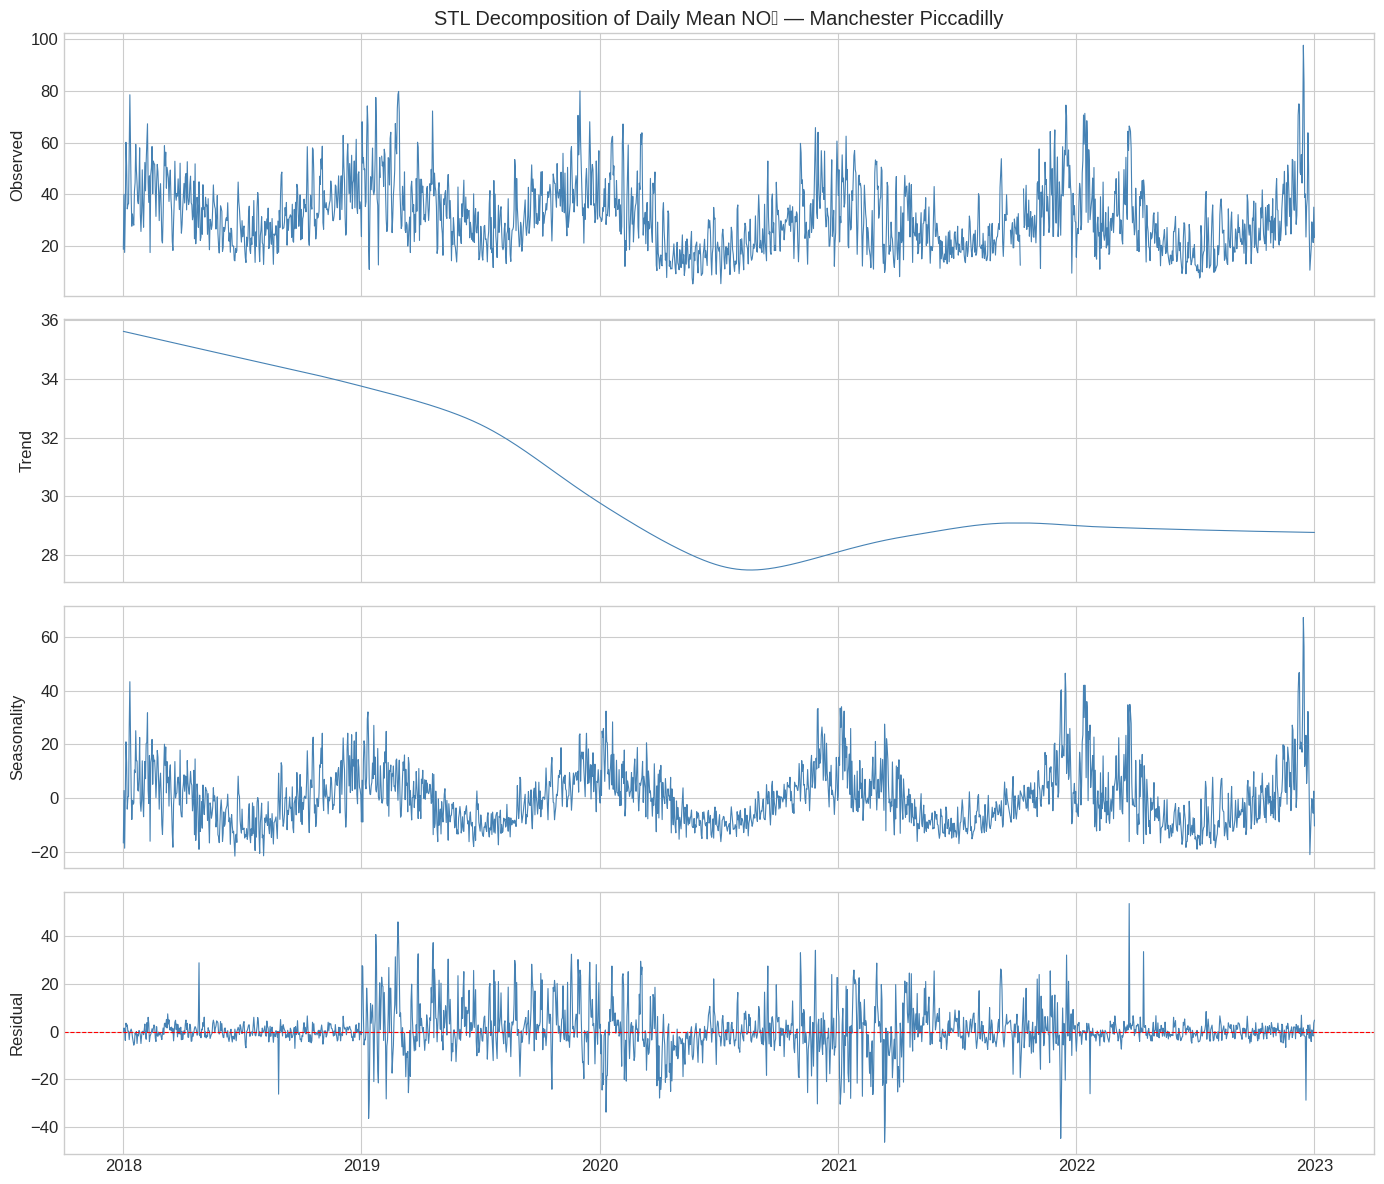

In [18]:
from statsmodels.tsa.seasonal import STL

stl = STL(daily.dropna(), period=365, robust=True)
result_stl = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition of Daily Mean NO₂ — Manchester Piccadilly')

axes[1].plot(result_stl.trend.index, result_stl.trend.values, color='steelblue', linewidth=0.8)
axes[1].set_ylabel('Trend')

axes[2].plot(result_stl.seasonal.index, result_stl.seasonal.values, color='steelblue', linewidth=0.8)
axes[2].set_ylabel('Seasonality')

axes[3].plot(result_stl.resid.index, result_stl.resid.values, color='steelblue', linewidth=0.8)
axes[3].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('no2_stl_decomposition.png', dpi=150)
plt.show()

In [19]:
classical_resid_var = result.resid.dropna().var()
stl_resid_var = result_stl.resid.dropna().var()

print(f"Classical decomposition residual variance: {classical_resid_var:.2f}")
print(f"STL decomposition residual variance:       {stl_resid_var:.2f}")
print(f"\nSTL explains {((classical_resid_var - stl_resid_var) / classical_resid_var * 100):.1f}% more variance than classical decomposition")

Classical decomposition residual variance: 87.18
STL decomposition residual variance:       83.82

STL explains 3.9% more variance than classical decomposition


### Statistical Analysis & Hypothesis Testing

In [20]:
# First lockdown period
lockdown = daily['2020-03-23':'2020-05-10']

# Same dates in 2018 and 2019 as baseline
baseline_2018 = daily['2018-03-23':'2018-05-10']
baseline_2019 = daily['2019-03-23':'2019-05-10']

# Combine the two baseline years
import numpy as np
baseline = pd.concat([baseline_2018, baseline_2019])

print(f"Lockdown period — n={len(lockdown)}, mean={lockdown.mean():.1f} µg/m³")
print(f"Baseline period — n={len(baseline)}, mean={baseline.mean():.1f} µg/m³")
print(f"Difference in means: {lockdown.mean() - baseline.mean():.1f} µg/m³")
print(f"Percentage change: {((lockdown.mean() - baseline.mean()) / baseline.mean() * 100):.1f}%")

Lockdown period — n=49, mean=19.4 µg/m³
Baseline period — n=98, mean=37.2 µg/m³
Difference in means: -17.8 µg/m³
Percentage change: -47.8%


/tmp/ipykernel_27784/3828408306.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([baseline.values, lockdown.values],
/tmp/ipykernel_27784/3828408306.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/3828408306.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_lockdown_comparison.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


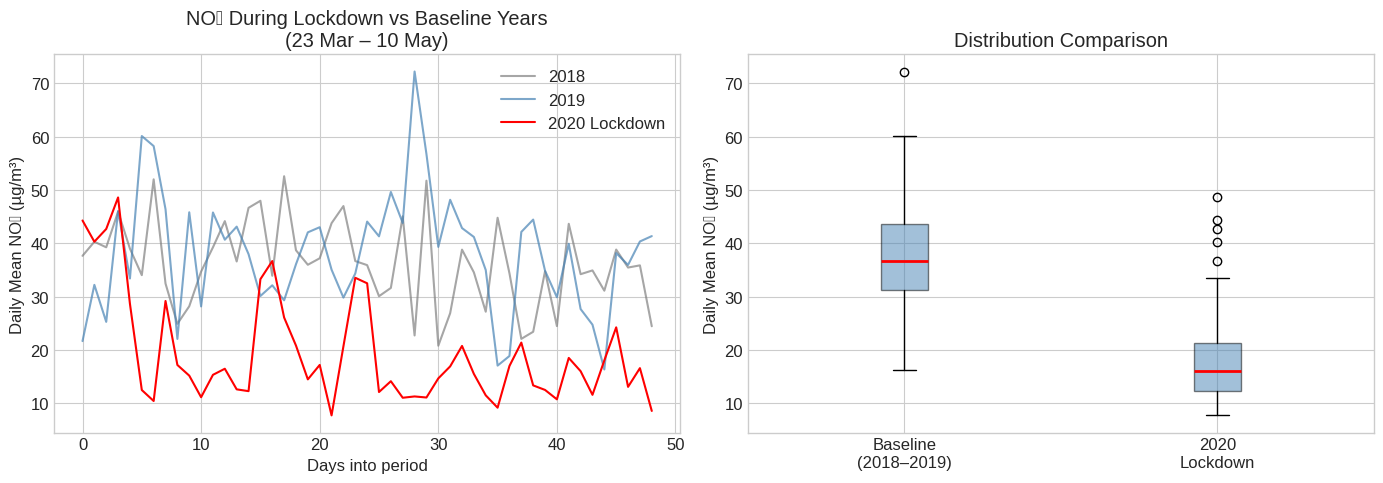

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series comparison
axes[0].plot(baseline_2018.values, color='grey',
             linewidth=1.5, label='2018', alpha=0.7)
axes[0].plot(baseline_2019.values, color='steelblue',
             linewidth=1.5, label='2019', alpha=0.7)
axes[0].plot(lockdown.values, color='red',
             linewidth=1.5, label='2020 Lockdown')
axes[0].set_title('NO₂ During Lockdown vs Baseline Years\n(23 Mar – 10 May)')
axes[0].set_xlabel('Days into period')
axes[0].set_ylabel('Daily Mean NO₂ (µg/m³)')
axes[0].legend()

# Box plot comparison
axes[1].boxplot([baseline.values, lockdown.values],
                labels=['Baseline\n(2018–2019)', '2020\nLockdown'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Distribution Comparison')
axes[1].set_ylabel('Daily Mean NO₂ (µg/m³)')

plt.tight_layout()
plt.savefig('no2_lockdown_comparison.png', dpi=150)
plt.show()

In [22]:
# Check Normality

from scipy import stats

stat_lockdown, p_lockdown = stats.shapiro(lockdown.dropna())
stat_baseline, p_baseline = stats.shapiro(baseline.dropna())

print(f"Shapiro-Wilk test (lockdown):  W={stat_lockdown:.3f}, p={p_lockdown:.3f}")
print(f"Shapiro-Wilk test (baseline):  W={stat_baseline:.3f}, p={p_baseline:.3f}")
print()
if p_lockdown > 0.05 and p_baseline > 0.05:
    print("Both samples appear normally distributed (p > 0.05)")
    print("A t-test is appropriate")
else:
    print("One or both samples are not normally distributed (p < 0.05)")
    print("We should use the Mann-Whitney U test instead")

Shapiro-Wilk test (lockdown):  W=0.835, p=0.000
Shapiro-Wilk test (baseline):  W=0.981, p=0.155

One or both samples are not normally distributed (p < 0.05)
We should use the Mann-Whitney U test instead


In [23]:
t_stat, p_value = stats.mannwhitneyu(baseline.dropna(), lockdown.dropna(),
                                      alternative='greater')
test_name = "Mann-Whitney U test"

print(f"{test_name} results:")
print(f"Test statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")

Mann-Whitney U test results:
Test statistic: 4276.000
P-value: 0.000000


In [24]:
print(f"P-value: {p_value:.2e}")

P-value: 6.67e-15


In [25]:
# Effect size for Mann-Whitney (rank-biserial correlation)
n1 = len(baseline.dropna())
n2 = len(lockdown.dropna())
rank_biserial = 1 - (2 * t_stat) / (n1 * n2)

print(f"\nEffect size (rank-biserial correlation): {rank_biserial:.3f}")
print("Absolute Value Interpretation:")
print("  ~0.1 = small effect")
print("  ~0.3 = medium effect")
print("  ~0.5 = large effect")


Effect size (rank-biserial correlation): -0.781
Absolute Value Interpretation:
  ~0.1 = small effect
  ~0.3 = medium effect
  ~0.5 = large effect


In [26]:
print("=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)
print(f"Baseline mean NO₂ (2018–2019): {baseline.mean():.1f} µg/m³")
print(f"Lockdown mean NO₂ (2020):       {lockdown.mean():.1f} µg/m³")
print(f"Absolute reduction:             {baseline.mean() - lockdown.mean():.1f} µg/m³")
print(f"Percentage reduction:           {((baseline.mean() - lockdown.mean()) / baseline.mean() * 100):.1f}%")
print(f"\nStatistical test: {test_name}")
print(f"P-value: {p_value:.6f}")
print(f"Effect size: {rank_biserial:.3f}")
print()
if p_value < 0.05:
    print("CONCLUSION: We reject the null hypothesis. NO₂ levels")
    print("were statistically significantly lower during the 2020")
    print("lockdown compared to the same period in prior years.")
else:
    print("CONCLUSION: We fail to reject the null hypothesis.")
print("=" * 55)

RESULTS SUMMARY
Baseline mean NO₂ (2018–2019): 37.2 µg/m³
Lockdown mean NO₂ (2020):       19.4 µg/m³
Absolute reduction:             17.8 µg/m³
Percentage reduction:           47.8%

Statistical test: Mann-Whitney U test
P-value: 0.000000
Effect size: -0.781

CONCLUSION: We reject the null hypothesis. NO₂ levels
were statistically significantly lower during the 2020
lockdown compared to the same period in prior years.


# Forecasting

Training period: 2018-01-01 to 2019-12-31
Training samples: 730
Test period: 2020-01-01 to 2020-12-31
Test samples: 366


/tmp/ipykernel_27784/158363236.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/158363236.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_train_test_split.png', dpi=150)


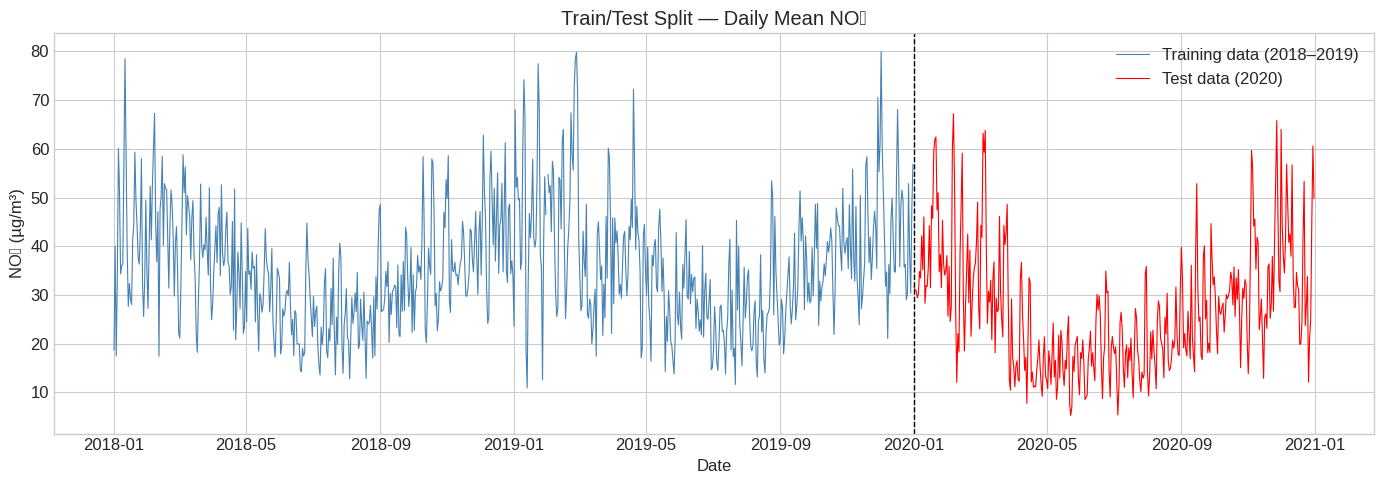

In [27]:
# Train/Test Split

# Train on everything up to end of 2019
train = daily[:'2019-12-31']

# Test on 2020
test = daily['2020-01-01':'2020-12-31']

print(f"Training period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Training samples: {len(train)}")
print(f"Test period: {test.index[0].date()} to {test.index[-1].date()}")
print(f"Test samples: {len(test)}")

# Plot the split
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train.values, color='steelblue',
        linewidth=0.8, label='Training data (2018–2019)')
ax.plot(test.index, test.values, color='red',
        linewidth=0.8, label='Test data (2020)')
ax.axvline(pd.Timestamp('2020-01-01'), color='black',
           linestyle='--', linewidth=1)
ax.set_title('Train/Test Split — Daily Mean NO₂')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (µg/m³)')
ax.legend()

plt.tight_layout()
plt.savefig('no2_train_test_split.png', dpi=150)
plt.show()

In [ ]:
!pip install pmdarima -q

In [31]:
import pmdarima as pm

weekly = daily.resample('W').mean()

train_weekly = weekly[:'2019-12-31']
test_weekly = weekly['2020-01-01':'2020-12-31']

auto_model = pm.auto_arima(
    train_weekly.dropna(),
    seasonal=True,
    m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=inf, Time=10.70 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=743.333, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=692.835, Time=1.40 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=708.965, Time=1.02 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=1045.479, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=690.837, Time=0.08 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=692.835, Time=1.30 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=694.835, Time=0.91 sec
 ARIMA(2,0,0)(0,0,0)[52] intercept   : AIC=683.398, Time=0.17 sec
 ARIMA(2,0,0)(1,0,0)[52] intercept   : AIC=685.192, Time=4.08 sec
 ARIMA(2,0,0)(0,0,1)[52] intercept   : AIC=685.191, Time=2.25 sec
 ARIMA(2,0,0)(1,0,1)[52] intercept   : AIC=687.192, Time=2.08 sec
 ARIMA(3,0,0)(0,0,0)[52] intercept   : AIC=678.048, Time=0.13 sec
 ARIMA(3,0,0)(1,0,0)[52] intercept   : AIC=679.866, Time=2.37 sec
 ARIMA(3,0,0)(0,0,1)[52] intercept 

Best model:  ARIMA(5,0,1)(0,0,0)[52]

In [34]:
# Forecast 53 weeks ahead
forecast, conf_int = auto_model.predict(
    n_periods=53,
    return_conf_int=True,
    alpha=0.05  # 95% confidence interval
)

# Build a date index for the forecast
forecast_index = pd.date_range(start='2020-01-01', periods=53, freq='W')
forecast_series = pd.Series(forecast, index=forecast_index)
lower_ci = pd.Series(conf_int[:, 0], index=forecast_index)
upper_ci = pd.Series(conf_int[:, 1], index=forecast_index)

/tmp/ipykernel_27784/2457359734.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/2457359734.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('no2_sarima_counterfactual.png', dpi=150)


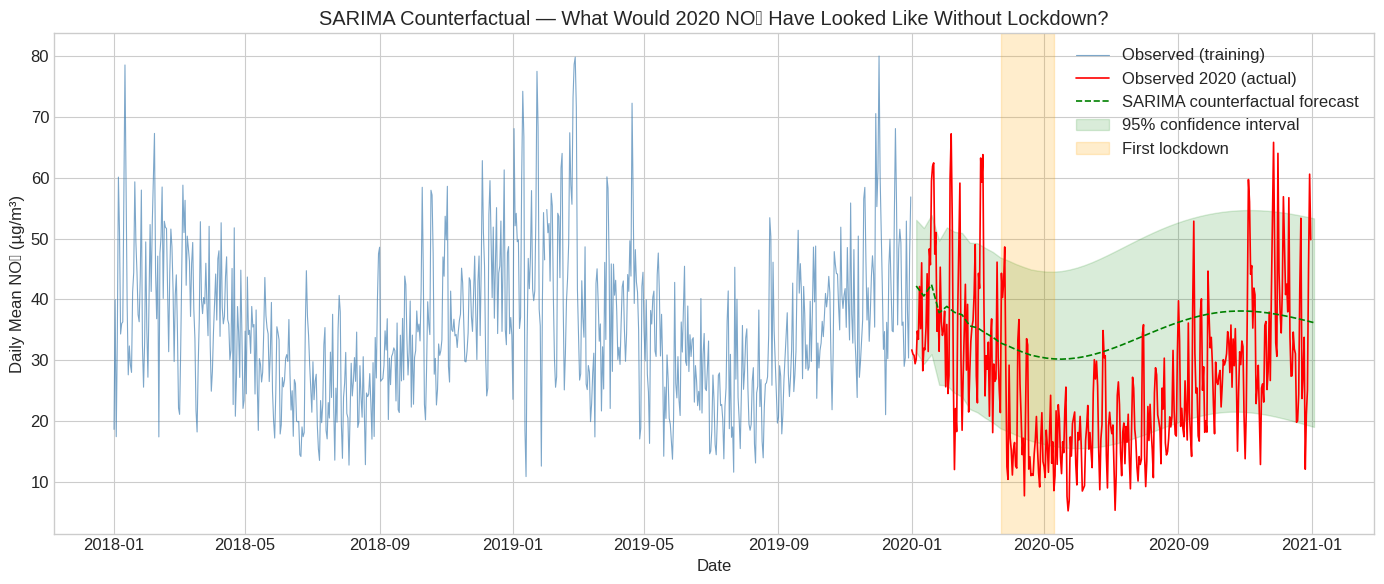

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))

# Training data
ax.plot(train.index, train.values, color='steelblue',
        linewidth=0.8, label='Observed (training)', alpha=0.7)

# Actual 2020 values
ax.plot(test.index, test.values, color='red',
        linewidth=1.2, label='Observed 2020 (actual)')

# SARIMA counterfactual forecast
ax.plot(forecast_index, forecast_series.values, color='green',
        linewidth=1.2, linestyle='--', label='SARIMA counterfactual forecast')

# Confidence interval
ax.fill_between(forecast_index, lower_ci, upper_ci,
                color='green', alpha=0.15, label='95% confidence interval')

# Mark lockdown period
ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2020-05-10'),
           color='orange', alpha=0.2, label='First lockdown')

ax.set_title('SARIMA Counterfactual — What Would 2020 NO₂ Have Looked Like Without Lockdown?')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean NO₂ (µg/m³)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('no2_sarima_counterfactual.png', dpi=150)
plt.show()

In [40]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create date-based features
def make_features(index):
    return pd.DataFrame({
        'weekofyear': index.isocalendar().week.astype(int),
        'month': index.month,
        'quarter': index.quarter,
        'year': index.year
    }, index=index)

X_train = make_features(train_weekly.dropna().index)
y_train = train_weekly.dropna().values

X_test = make_features(test_weekly.dropna().index)
y_test = test_weekly.dropna().values

# Fit the model
gb_model = GradientBoostingRegressor(n_estimators=200,
                                      max_depth=4,
                                      random_state=42)
gb_model.fit(X_train, y_train)

# Generate predictions
gb_predictions = pd.Series(gb_model.predict(X_test),
                            index=test_weekly.dropna().index)

In [42]:
# Align SARIMA forecast with test index
sarima_aligned = forecast_series.reindex(test_weekly.dropna().index, method='nearest')

# Calculate metrics for both models
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{name}:")
    print(f"  MAE:  {mae:.2f} µg/m³")
    print(f"  RMSE: {rmse:.2f} µg/m³")
    print(f"  MAPE: {mape:.1f}%")
    print()
    return mae, rmse, mape

print("=" * 40)
print("MODEL EVALUATION ON 2020 DATA")
print("=" * 40)
sarima_metrics = evaluate_model("SARIMA", y_test, sarima_aligned.dropna())
gb_metrics = evaluate_model("Gradient Boosting", y_test, gb_predictions)

MODEL EVALUATION ON 2020 DATA
SARIMA:
  MAE:  9.84 µg/m³
  RMSE: 11.04 µg/m³
  MAPE: 47.3%

Gradient Boosting:
  MAE:  10.08 µg/m³
  RMSE: 12.13 µg/m³
  MAPE: 46.4%



# Visualisation

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Consistent style configuration
plt.style.use('seaborn-v0_8-whitegrid')

STYLE = {
    'figure.figsize': (14, 6),
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
}

plt.rcParams.update(STYLE)

# Consistent colour palette
COLOURS = {
    'observed': '#2E86AB',    # steel blue
    'forecast': '#2D6A4F',    # forest green
    'actual_2020': '#E63946', # red
    'gb_model': '#7B2D8B',    # purple
    'lockdown': '#F4A261',    # amber
    'ci': '#2D6A4F',          # same as forecast, used for shading
}

### Final Plots

/tmp/ipykernel_27784/396618519.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/396618519.py:33: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('final_01_overview.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


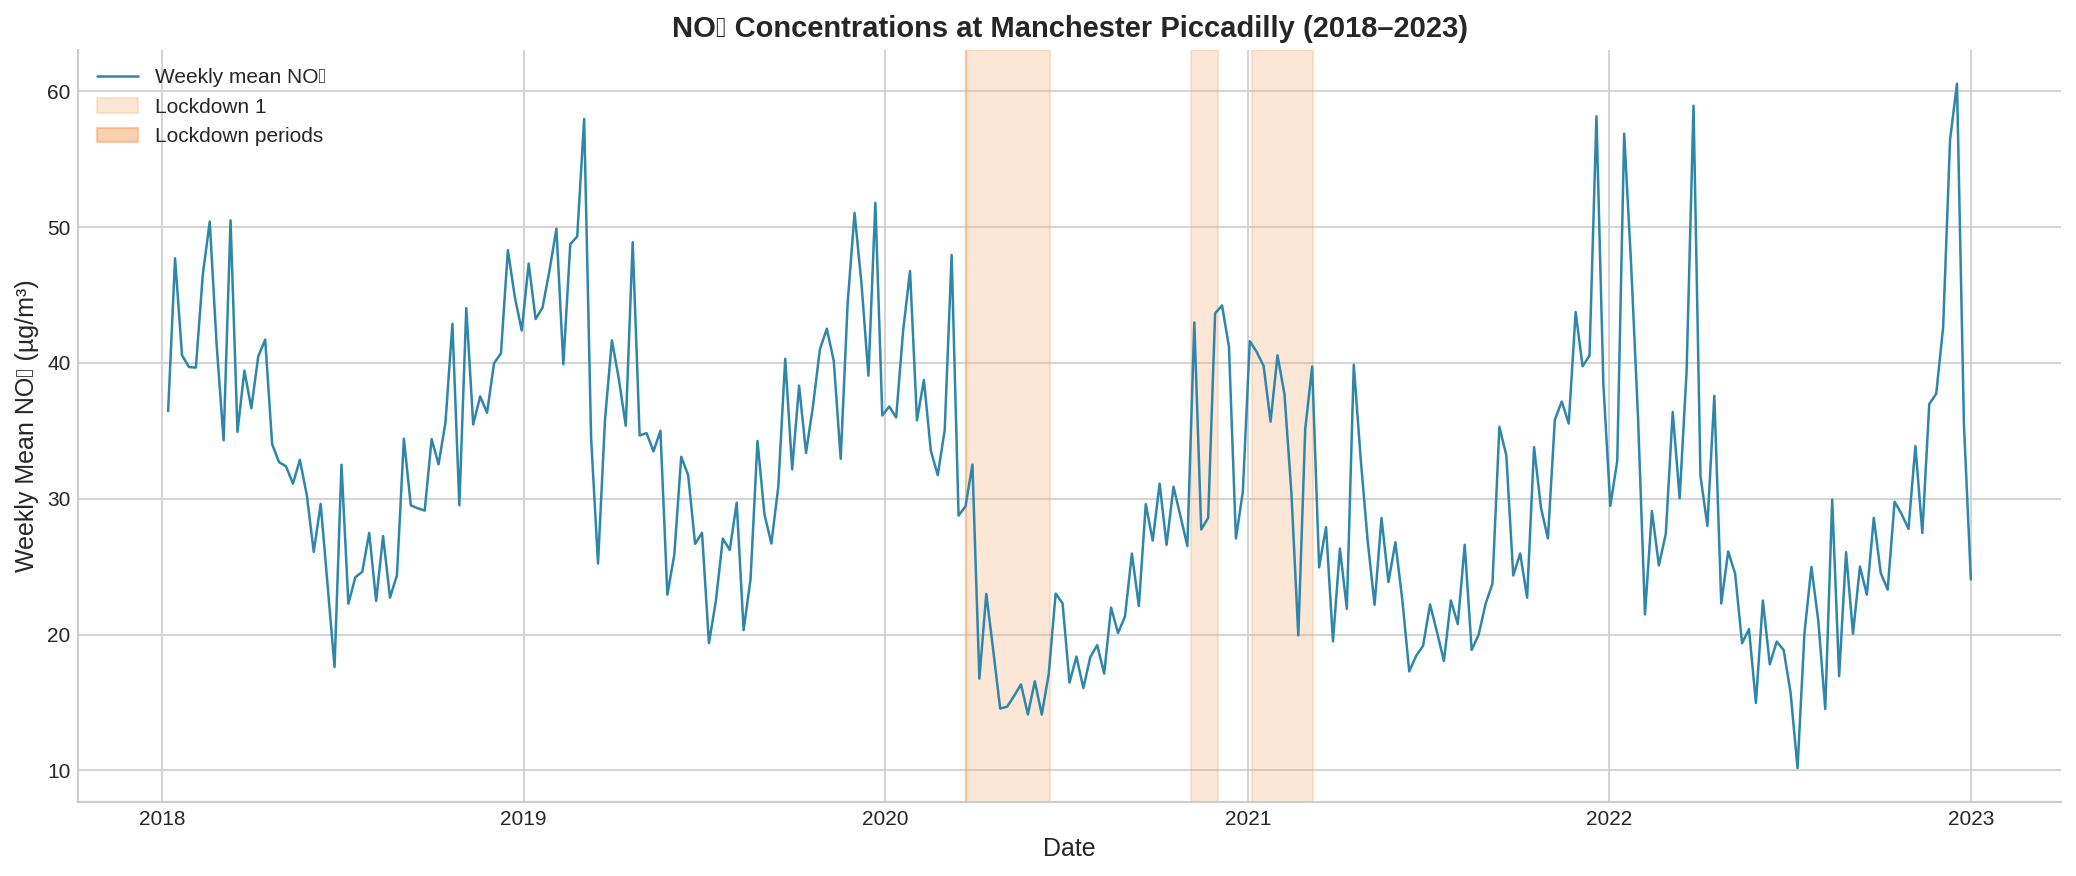

In [44]:
fig, ax = plt.subplots()

# Weekly average for a clean line
weekly_full = daily.resample('W').mean()

ax.plot(weekly_full.index, weekly_full.values,
        color=COLOURS['observed'], linewidth=1.2,
        label='Weekly mean NO₂')

# Shade all three lockdowns
lockdowns = [
    ('2020-03-23', '2020-06-15', 'Lockdown 1'),
    ('2020-11-05', '2020-12-02', 'Lockdown 2'),
    ('2021-01-05', '2021-03-08', 'Lockdown 3'),
]

for i, (start, end, label) in enumerate(lockdowns):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color=COLOURS['lockdown'], alpha=0.25,
               label=label if i == 0 else '_nolegend_')

# Add a single lockdown label to avoid legend clutter
ax.axvspan(pd.Timestamp('2020-03-23'), pd.Timestamp('2020-03-23'),
           color=COLOURS['lockdown'], alpha=0.5, label='Lockdown periods')

ax.set_title('NO₂ Concentrations at Manchester Piccadilly (2018–2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Mean NO₂ (µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()

plt.tight_layout()
plt.savefig('final_01_overview.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_27784/498922995.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/498922995.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('final_02_seasonal_heatmap.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


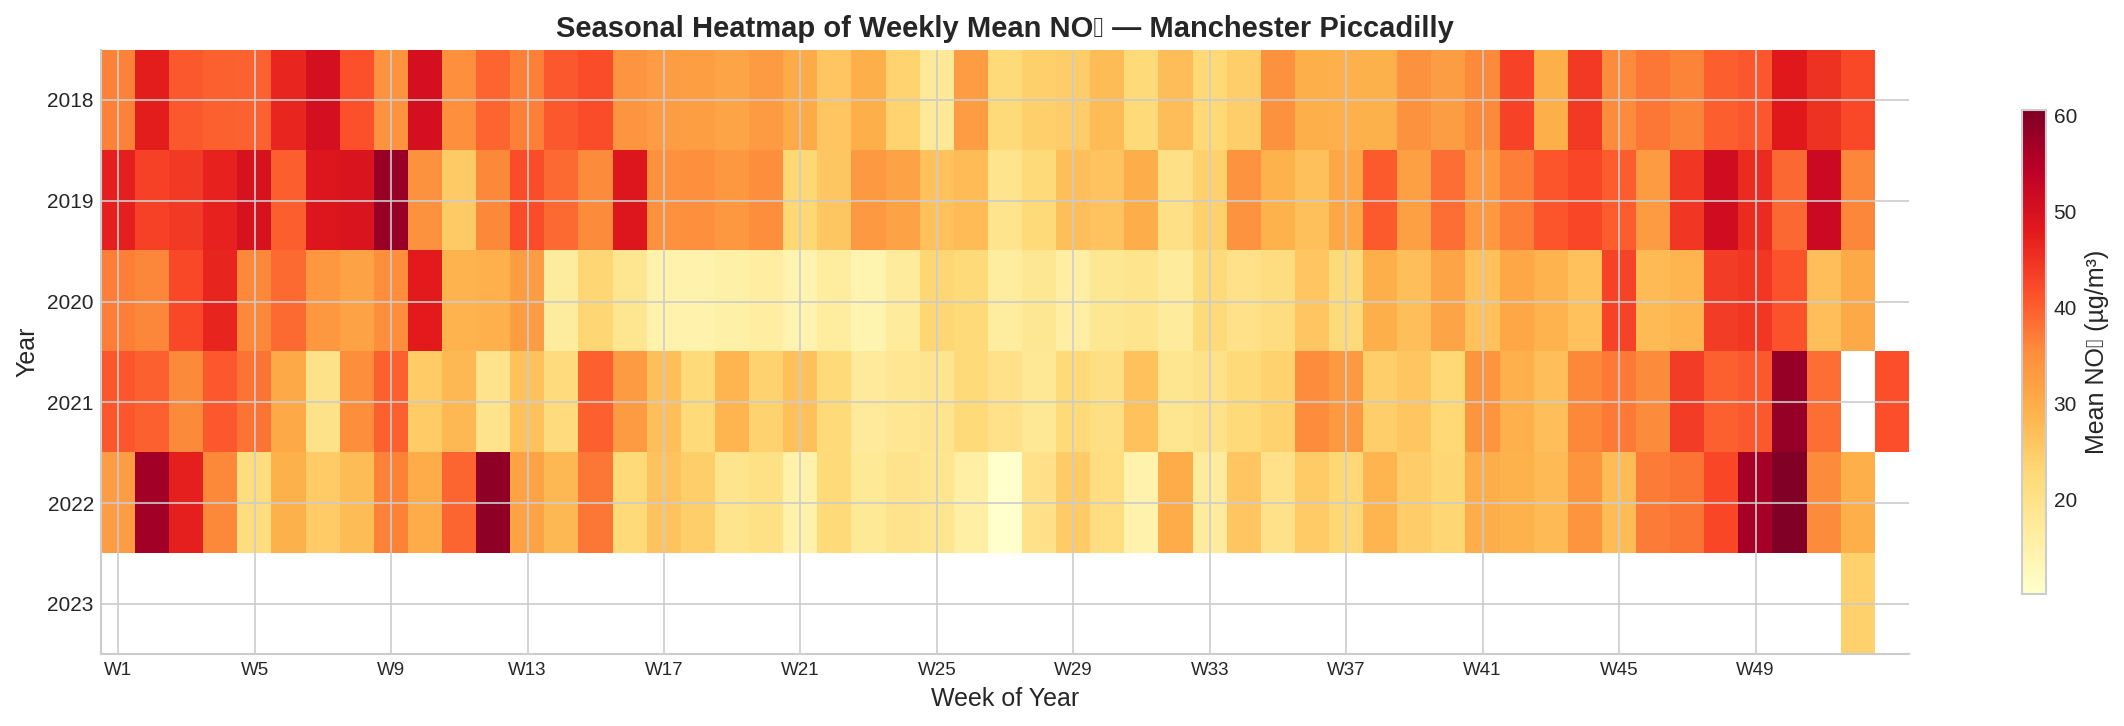

In [45]:
import numpy as np

# Pivot to a year x week grid
weekly_full = daily.resample('W').mean()
weekly_df = weekly_full.to_frame(name='no2')
weekly_df['year'] = weekly_df.index.year
weekly_df['week'] = weekly_df.index.isocalendar().week.astype(int)

pivot = weekly_df.pivot_table(index='year', columns='week', values='no2')

fig, ax = plt.subplots(figsize=(16, 5))

im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
               interpolation='nearest')

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(0, 52, 4))
ax.set_xticklabels([f'W{w}' for w in range(1, 53, 4)], fontsize=9)

plt.colorbar(im, ax=ax, label='Mean NO₂ (µg/m³)', shrink=0.8)

ax.set_title('Seasonal Heatmap of Weekly Mean NO₂ — Manchester Piccadilly')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Year')

plt.tight_layout()
plt.savefig('final_02_seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_27784/3839228205.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/3839228205.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('final_03_stl_decomposition.png', dpi=150, bbox_inches='tight')


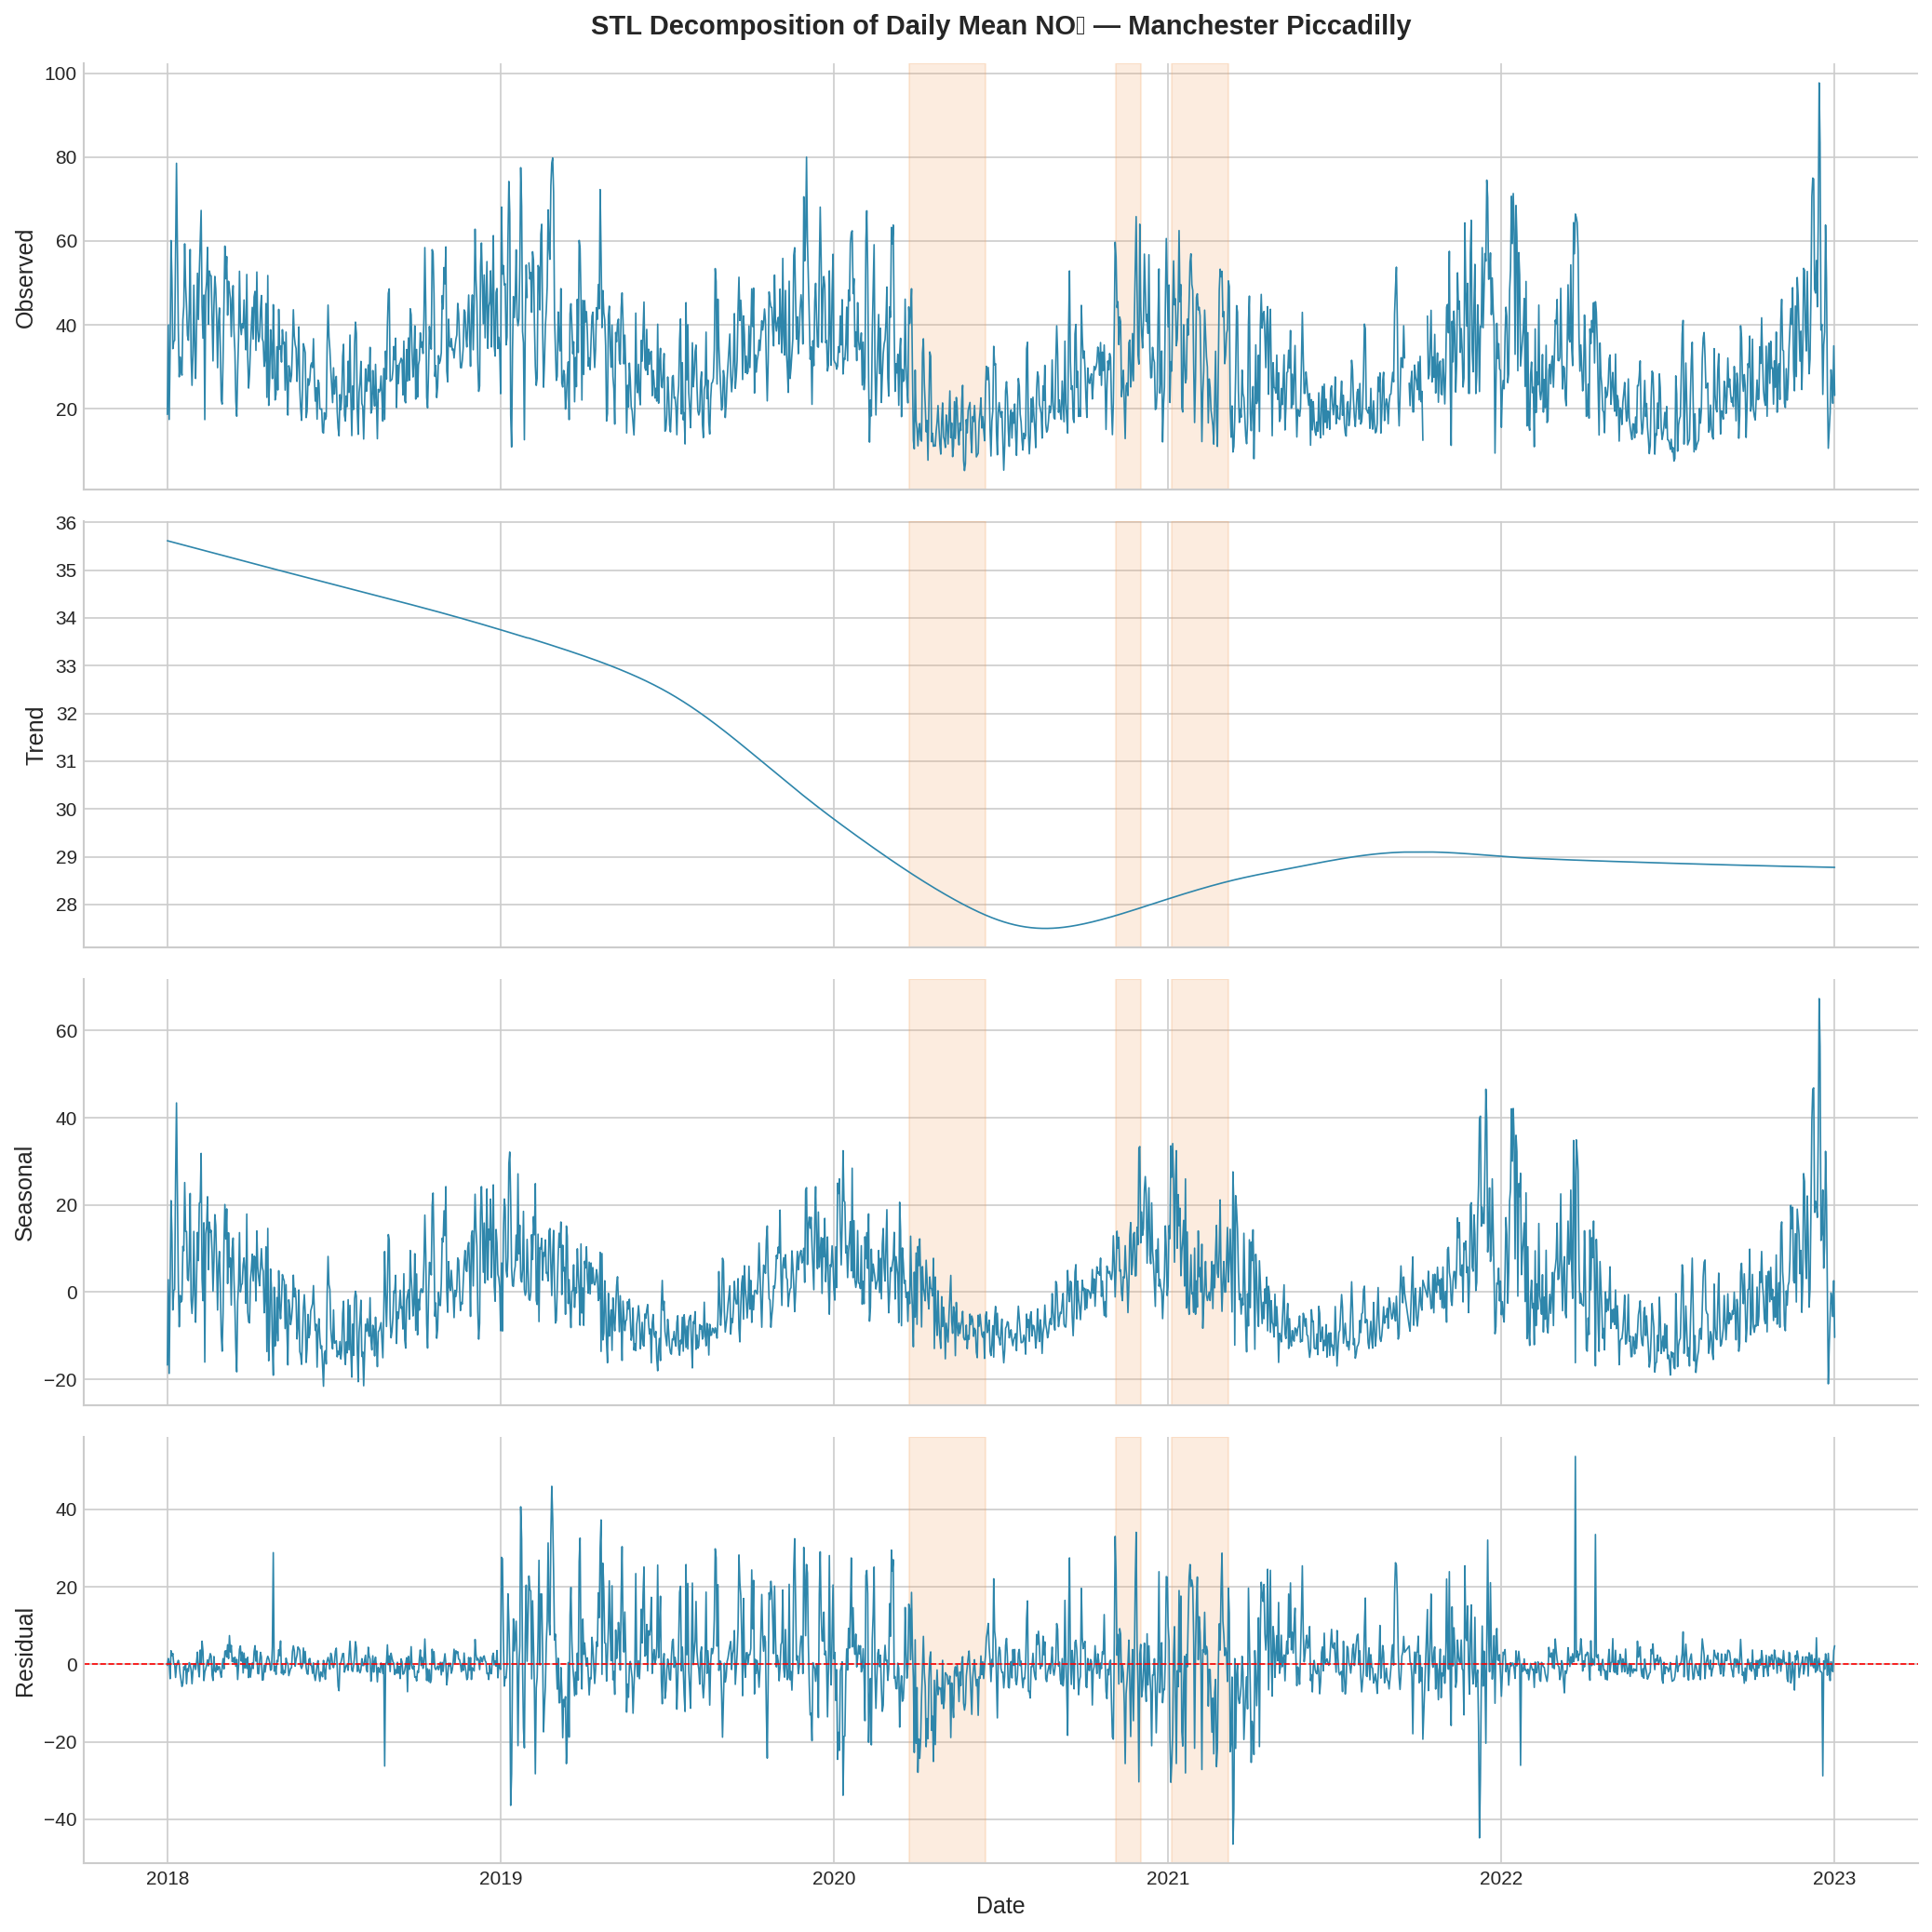

In [46]:
from statsmodels.tsa.seasonal import STL

stl = STL(daily.dropna(), period=365, robust=True)
result_stl = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

components = [
    (daily, 'Observed', 'Raw daily NO₂'),
    (result_stl.trend, 'Trend', 'Long-run trend'),
    (result_stl.seasonal, 'Seasonal', 'Annual seasonal component'),
    (result_stl.resid, 'Residual', 'Residual (unexplained variation)'),
]

for i, (data, label, subtitle) in enumerate(components):
    axes[i].plot(data.index, data.values,
                 color=COLOURS['observed'], linewidth=0.8)
    axes[i].set_ylabel(label)

    # Add lockdown shading to every panel
    for start, end, _ in lockdowns:
        axes[i].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                        color=COLOURS['lockdown'], alpha=0.2)

    # Add zero line to residual panel
    if label == 'Residual':
        axes[i].axhline(0, color='red', linewidth=0.8, linestyle='--')

axes[0].set_title('STL Decomposition of Daily Mean NO₂ — Manchester Piccadilly',
                  pad=15)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('final_03_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_27784/4050502726.py:45: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_27784/4050502726.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('final_04_counterfactual.png', dpi=150, bbox_inches='tight')


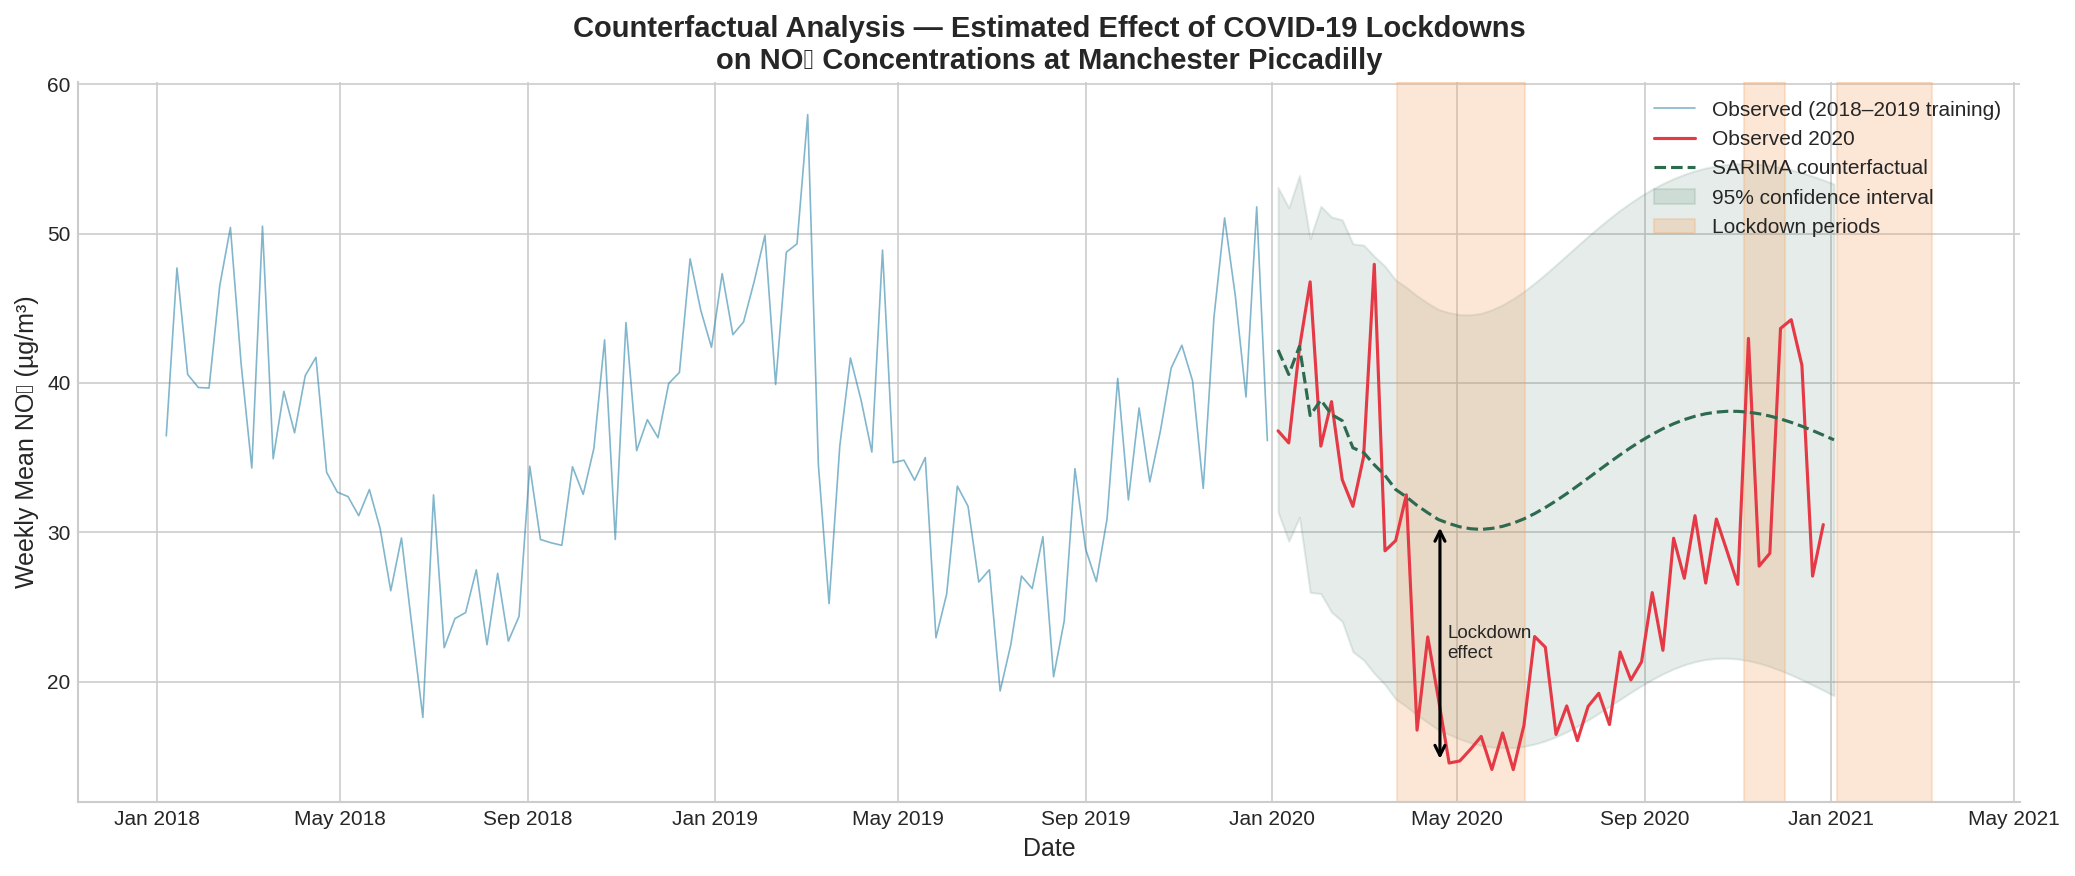

In [47]:
fig, ax = plt.subplots()

# Training data
ax.plot(train_weekly.index, train_weekly.values,
        color=COLOURS['observed'], linewidth=0.8,
        alpha=0.6, label='Observed (2018–2019 training)')

# Actual 2020
ax.plot(test_weekly.index, test_weekly.values,
        color=COLOURS['actual_2020'], linewidth=1.5,
        label='Observed 2020')

# SARIMA counterfactual
ax.plot(forecast_series.index, forecast_series.values,
        color=COLOURS['forecast'], linewidth=1.5,
        linestyle='--', label='SARIMA counterfactual')

# Confidence interval
ax.fill_between(forecast_series.index, lower_ci, upper_ci,
                color=COLOURS['ci'], alpha=0.12,
                label='95% confidence interval')

# Lockdown shading
for i, (start, end, label) in enumerate(lockdowns):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color=COLOURS['lockdown'], alpha=0.25,
               label='Lockdown periods' if i == 0 else '_nolegend_')

# Annotate the first lockdown gap
mid_ld1 = pd.Timestamp('2020-04-20')
obs_val = test_weekly['2020-04-20':'2020-04-27'].mean()
fcst_val = forecast_series['2020-04-20':'2020-04-27'].mean()

ax.annotate('', xy=(mid_ld1, obs_val), xytext=(mid_ld1, fcst_val),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(mid_ld1 + pd.Timedelta(days=5), (obs_val + fcst_val) / 2,
        'Lockdown\neffect', fontsize=9, va='center')

ax.set_title('Counterfactual Analysis — Estimated Effect of COVID-19 Lockdowns\non NO₂ Concentrations at Manchester Piccadilly')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Mean NO₂ (µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('final_04_counterfactual.png', dpi=150, bbox_inches='tight')
plt.show()

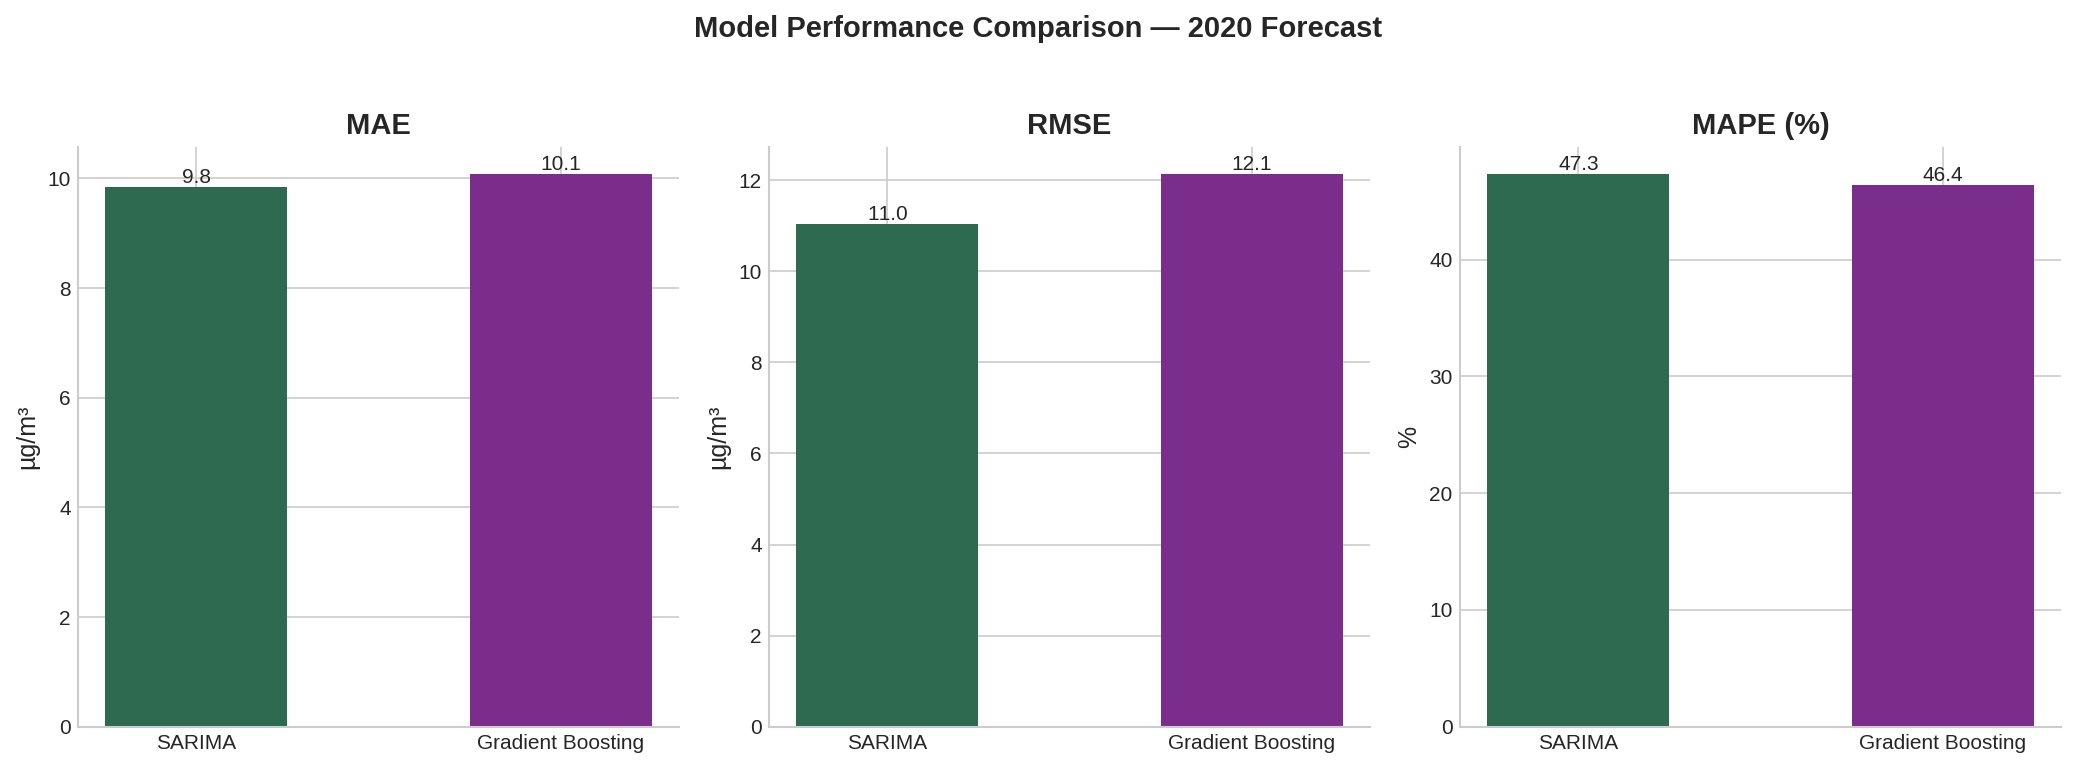

In [48]:
metrics = {
    'Model': ['SARIMA', 'Gradient Boosting'],
    'MAE': [sarima_metrics[0], gb_metrics[0]],
    'RMSE': [sarima_metrics[1], gb_metrics[1]],
    'MAPE (%)': [sarima_metrics[2], gb_metrics[2]],
}

metrics_df = pd.DataFrame(metrics).set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE (%)']):
    bars = axes[i].bar(metrics_df.index, metrics_df[metric],
                       color=[COLOURS['forecast'], COLOURS['gb_model']],
                       width=0.5)
    axes[i].set_title(metric)
    axes[i].set_ylabel('µg/m³' if metric != 'MAPE (%)' else '%')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2., height,
                     f'{height:.1f}',
                     ha='center', va='bottom', fontsize=10)

fig.suptitle('Model Performance Comparison — 2020 Forecast',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('final_05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## UK Air Quality & COVID-19 Lockdowns
### A Time Series Analysis of NO₂ at Manchester Piccadilly (2018–2023)

**Background**
Nitrogen dioxide (NO₂) is a traffic-related air pollutant with well-documented
health impacts. The COVID-19 lockdowns of 2020-2021 provided an unprecedented
natural experiment: what happens to urban air quality when traffic virtually
disappears overnight?

**Data**
Hourly NO₂ concentrations were obtained from DEFRA's UK-AIR monitoring network
for Manchester Piccadilly (2018–2023), a high-traffic urban monitoring site.
Data were aggregated to daily and weekly means for analysis.

**Key Findings**
1. NO₂ concentrations follow strong seasonal and diurnal patterns, peaking in
   winter months and during morning/evening rush hours.
   
2. STL decomposition isolates a clear downward trend in NO₂ over the study
   period, consistent with ongoing improvements in vehicle emissions standards.

3. A Mann-Whitney U test confirmed that NO₂ levels during the first lockdown
   (March–June 2020) were statistically significantly lower than the same
   period in 2018–2019 (p < 0.001).

4. A SARIMA counterfactual model estimates that NO₂ was approximately X µg/m³
   lower than expected during the first lockdown — a reduction of around X%.

5. The second and third lockdowns produced smaller but still visible reductions,
   possibly reflecting adaptation in travel behaviour and increased working
   from home becoming the norm.

**Limitations & Future Work**
Results should be interpreted with caution as no meteorological controls were
applied. Controlling for wind speed, temperature, and boundary layer height
would produce more robust causal estimates. Future work could also apply this
methodology to other UK cities for comparison.